## Step 0. Folder Structure
```
3. Deep Learning Project/
├── dataset_split/
│   ├── train/
│   │   ├── african_elephant (780 images)
│   │   ├── airliner (780 images)
│   │   └── ... (8 more folders)
│   ├── val/
│   │   ├── african_elephant (260 images)
│   │   ├── airliner (260 images)
│   │   └── ... (8 more folders)
│   └── test (2600 images)
├── data_preprocessed/
│   ├── labels_train.pt
│   ├── labels_val.pt
│   ├── tensor_test.pt
│   ├── tensor_train.pt
│   └── tensor_val.pt
├── models/
│   ├── resnet18_checkpoint.pkl
│   └── resnet34_checkpoint.pkl
├── src/
│   └── part3.ipynb
├── src_datasplit/
│   └── data_split.ipynb
├── MSA.yaml
├── README.md
└── IEEE_Report_Template.docx
```


In [1]:
# TODO: Import the libraries.
from typing import Tuple, List
import os
import cv2
from tqdm import tqdm
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from collections import OrderedDict
import copy
import matplotlib.pyplot as plt
import csv

## Step 1 Preprocessing
1. Load images and labels from folders into lists.
2. Resize the images.
3. Convert the image data type as float32 and limit the range in [0, 1].
4. Convert data from NHWC to NCHW and creat a PyTorch tensor from it.
5. Per-channel standardization of the dataset using training set statistics (mean and std computed independently for each color channel).
6. Saving the pre-processed sets as .pt files in the correct directory.
7. Load the pre-processed sets from .pt files. 

In [ ]:
# 1. Load images from folder into a list.
def image_loader(set_dir: str) -> Tuple[List[np.ndarray], List[str]]:
    """
    Load all images from a dataset directory (train/val/test) into memory.
    Make sure:
        1. Load training and validation set images and labels in the correct order.
        2. Load testing set images in filename order (e.g., 0.jpg, 1.jpg, ...).
    
    Parameters:
    -----------
    set_dir : str
        Path to the directory containing either:
        - Class subdirectories (for train/val sets)
        - Direct image files (for test set)
        
    Returns:
    --------
    Tuple[List[np.ndarray], List[str]]
        images: List of BGR images (HWC format, uint8 dtype)
        labels: List of string labels (empty for test set)
        
    Example:
    --------
    >>> images_train, labels_train = image_loader("../dataset_split/train")
    >>> images_test, _ = image_loader("../dataset_split/test")
    """
    
    images = []
    labels = []
    class_dirs = [d for d in os.listdir(set_dir) if os.path.isdir(os.path.join(set_dir,d))]
    
    if class_dirs:  
        for class_name in sorted(class_dirs):
            class_path = os.path.join(set_dir, class_name)
            
            image_files = sorted(os.listdir(class_path))
            for fname in image_files:
                fpath = os.path.join(class_path, fname)
                image = cv2.imread(fpath)
                if image is not None:
                    images.append(image)
                    labels.append(class_name)
    else: 
        image_files = sorted(os.listdir(set_dir), key=lambda x: int(x.split('.')[0]))
        for fname in image_files:
            fpath = os.path.join(set_dir, fname)
            image = cv2.imread(fpath)
            if image is not None:
                images.append(image)
        labels = []

    return images, labels

In [ ]:
# 2. Data preprocessing and dataset construction
def preprocess_and_split(images: List[np.ndarray], labels: List[str], test: bool = False) -> Tuple[TensorDataset, Optional[np.ndarray]]:
    """
    Preprocess images and construct a PyTorch TensorDataset.
    
    Parameters:
    -----------
    images : List[np.ndarray]
        List of BGR images (HWC format, uint8 dtype)
    labels : List[str]
        List of string labels (empty for test set)
    test : bool
        Whether this is the test set (no labels)
    
    Returns:
    --------
    dataset : TensorDataset
        PyTorch dataset containing image tensors and label tensors (if not test)
    label_array : np.ndarray or None
        Array of integer labels (if not test), None for test set
    """
    
    # Convert images to RGB and resize to 224x224
    images_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]
    images_resized = [cv2.resize(img, (224, 224)) for img in images_rgb]
    
    # Convert to numpy array and normalize to [0, 1]
    images_np = np.stack(images_resized).astype(np.float32) / 255.0
    images_np = np.transpose(images_np, (0, 3, 1, 2))  # NCHW
    
    if not test:
        # Encode labels as integers
        label_set = sorted(set(labels))
        label_to_idx = {label: idx for idx, label in enumerate(label_set)}
        labels_idx = np.array([label_to_idx[label] for label in labels], dtype=np.int64)
        
        # Create TensorDataset
        dataset = TensorDataset(torch.tensor(images_np), torch.tensor(labels_idx))
        return dataset, labels_idx
    else:
        # For test set, no labels
        dataset = TensorDataset(torch.tensor(images_np))
        return dataset, None

In [ ]:
# 3. DataLoader construction
def build_dataloaders(train_set: TensorDataset, val_set: TensorDataset, test_set: TensorDataset, batch_size: int = 32) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Build PyTorch DataLoaders for train, validation, and test sets.
    
    Parameters:
    -----------
    train_set : TensorDataset
        Training dataset
    val_set : TensorDataset
        Validation dataset
    test_set : TensorDataset
        Test dataset
    batch_size : int
        Batch size for DataLoaders
    
    Returns:
    --------
    Tuple[DataLoader, DataLoader, DataLoader]
        DataLoaders for train, validation, and test sets
    """
    
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

In [ ]:
# 4. Define ResNet18 and ResNet34 models for classification
def get_resnet_model(model_name: str, num_classes: int) -> nn.Module:
    """
    Get a ResNet model (ResNet18 or ResNet34) for classification.
    
    Parameters:
    -----------
    model_name : str
        'resnet18' or 'resnet34'
    num_classes : int
        Number of output classes
    
    Returns:
    --------
    nn.Module
        The specified ResNet model with modified output layer
    """
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=True)
    elif model_name == 'resnet34':
        model = models.resnet34(pretrained=True)
    else:
        raise ValueError('model_name must be "resnet18" or "resnet34"')
    
    # Replace the final fully connected layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [ ]:
# 5. Training function for normal ResNet18 (no knowledge distillation)
def train_normal(model, train_loader, val_loader, criterion, optimizer, scheduler, device, max_epoch):
    best_val_acc = 0.0
    best_epoch = 0
    train_accs = []
    val_accs = []
    train_losses = []
    val_losses = []
    
    for epoch in range(max_epoch):
        model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_x.size(0)
        
        train_acc = correct / total
        train_losses.append(train_loss / total)
        train_accs.append(train_acc)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == batch_y).sum().item()
                total += batch_x.size(0)
        val_acc = correct / total
        val_losses.append(val_loss / total)
        val_accs.append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{max_epoch} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")
    
    print(f"Best Val Acc: {best_val_acc:.4f} at epoch {best_epoch}")
    return train_accs, val_accs, train_losses, val_losses, best_val_acc, best_epoch

In [ ]:
# 6. Training function for ResNet18 with knowledge distillation from ResNet34
def train_kd(student_model, teacher_model, train_loader, val_loader, criterion, optimizer, scheduler, device, max_epoch, temperature=4, alpha=0.9):
    best_val_acc = 0.0
    best_epoch = 0
    train_accs = []
    val_accs = []
    train_losses = []
    val_losses = []
    
    teacher_model.eval()
    
    for epoch in range(max_epoch):
        student_model.train()
        train_loss = 0.0
        correct = 0
        total = 0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            student_outputs = student_model(batch_x)
            with torch.no_grad():
                teacher_outputs = teacher_model(batch_x)
            
            # Knowledge distillation loss
            loss_kd = nn.KLDivLoss(reduction='batchmean')(nn.functional.log_softmax(student_outputs/temperature, dim=1), nn.functional.softmax(teacher_outputs/temperature, dim=1)) * (temperature ** 2)
            loss_ce = criterion(student_outputs, batch_y)
            loss = alpha * loss_kd + (1 - alpha) * loss_ce
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
            _, predicted = torch.max(student_outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total += batch_x.size(0)
        
        train_acc = correct / total
        train_losses.append(train_loss / total)
        train_accs.append(train_acc)
        
        # Validation
        student_model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = student_model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == batch_y).sum().item()
                total += batch_x.size(0)
        val_acc = correct / total
        val_losses.append(val_loss / total)
        val_accs.append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{max_epoch} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")
    
    print(f"Best Val Acc: {best_val_acc:.4f} at epoch {best_epoch}")
    return train_accs, val_accs, train_losses, val_losses, best_val_acc, best_epoch

In [ ]:
# 7. Evaluation function for model performance
def evaluate(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

In [ ]:
# 8. Compute metrics: accuracy, precision, recall, F1, top-3 accuracy
def compute_metrics(y_true, y_pred, y_logits=None, num_classes=None):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    top3 = None
    if y_logits is not None and num_classes is not None:
        # Calculate top-3 accuracy
        top3_preds = np.argsort(y_logits, axis=1)[:, -3:]
        top3 = np.mean([y_true[i] in top3_preds[i] for i in range(len(y_true))])
    return acc, precision, recall, f1, top3

['african_elephant', 'airliner', 'banana', 'convertible_car', 'golden_retriever', 'goldfish', 'parachute', 'rugby', 'sunglasses', 'tiger_cat']
{'african_elephant': 0, 'airliner': 1, 'banana': 2, 'convertible_car': 3, 'golden_retriever': 4, 'goldfish': 5, 'parachute': 6, 'rugby': 7, 'sunglasses': 8, 'tiger_cat': 9}
tensor([0, 0, 0,  ..., 9, 9, 9])


In [ ]:
# 9. Plot training and validation metrics
def plot_metrics(train_metrics, val_metrics, metric_name, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_metrics, label=f'Train {metric_name}')
    plt.plot(val_metrics, label=f'Val {metric_name}')
    plt.xlabel('Epoch')
    plt.ylabel(metric_name)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

C:\Users\Wade Yan\AppData\Local\Temp\ipykernel_33576\563408691.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor_train = torch.load("../data_preprocessed/tensor_tra

# Step 2 Train the teacher model (ResNet34)
1. Set hyperparameters for the training process.
2. Create a pretrained ResNet34.
3. Define the optimizer, loss function, etc.
4. Train ResNet34 and save the best-performing parameters to 'resnet34_checkpoint.pkl'.
5. Plot the loss and accuracy curves.

In [ ]:
# 10. Save model checkpoint
def save_checkpoint(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")

tensor(10)
torch.Size([7800, 3, 224, 224])
torch.Size([2600, 3, 224, 224])
torch.Size([2600, 3, 224, 224])
torch.Size([7800])
torch.Size([2600])


In [ ]:
# 11. Load model checkpoint
def load_checkpoint(model, path, device):
    model.load_state_dict(torch.load(path, map_location=device))
    print(f"Model loaded from {path}")

In [ ]:
# 12. Generate submission file for test set predictions
def generate_submission(model, test_loader, device, index_to_label, output_path):
    model.eval()
    submission_rows = []
    with torch.no_grad():
        for i, (batch_x,) in enumerate(test_loader):
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            _, predicted = torch.max(outputs, 1)
            for pred in predicted.cpu().numpy():
                submission_rows.append(index_to_label[pred])
    
    with open(output_path, 'w') as f:
        f.write('Category\n')
        for row in submission_rows:
            f.write(f'{row}\n')
    print(f"Submission file saved to {output_path}")

d:\anaconda\envs\MSA\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\envs\MSA\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# 13. Utility: Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
# 14. Utility: Print metrics for each epoch
def print_epoch_metrics(epoch, train_loss, train_acc, val_loss, val_acc):
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

Training Epochs:  10%|█         | 1/10 [00:27<04:10, 27.88s/it]

Epoch 1/10 | Train Loss: 0.5584, Acc: 0.8799 | Val Loss: 0.1547, Acc: 0.9708  <-- Best model saved.


Training Epochs:  20%|██        | 2/10 [00:53<03:31, 26.40s/it]

Epoch 2/10 | Train Loss: 0.1274, Acc: 0.9762 | Val Loss: 0.1036, Acc: 0.9750  <-- Best model saved.


Training Epochs:  30%|███       | 3/10 [01:18<03:01, 25.86s/it]

...

Epoch 8/10 | Train Loss: 0.0420, Acc: 0.9901 | Val Loss: 0.0615, Acc: 0.9827  <-- Best model saved.


Training Epochs:  90%|█████████ | 9/10 [03:54<00:26, 26.11s/it]

Epoch 9/10 | Train Loss: 0.0414, Acc: 0.9899 | Val Loss: 0.0609, Acc: 0.9812  <-- Best model saved.


Training Epochs: 100%|██████████| 10/10 [04:20<00:00, 26.04s/it]

Epoch 10/10 | Train Loss: 0.0353, Acc: 0.9927 | Val Loss: 0.0605, Acc: 0.9823  <-- Best model saved.


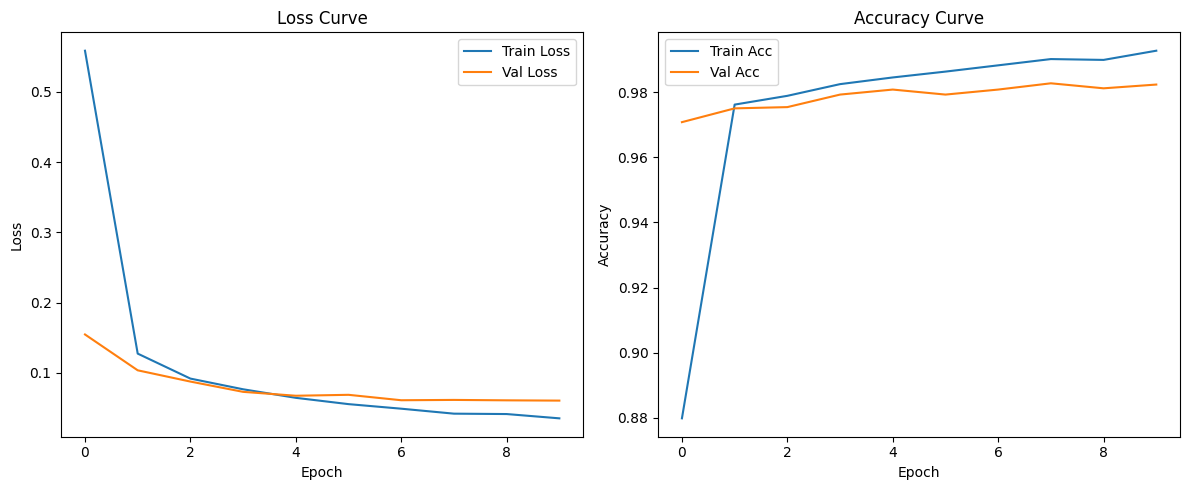

KD Train Accuracy: 0.9927
KD Val Accuracy: 0.9827


In [ ]:
# 15. Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Step 3 Train the student model (ResNet18)
1. Set hyperparameters for the distillation process.
2. Create a NON-PRETRAINED ResNet18 and move the model to selected device.
3. Load the saved ResNet34 and move the model to selected device.
4. Define the optimizer, loss function, etc.
5. Train ResNet18 and save the best-performing parameters to 'resnet18_checkpoint.pkl'.
6. Plot the loss and accuracy curves.

In [ ]:
# 16. Utility: Print best accuracy and related metrics
def print_best_metrics(best_val_acc, best_epoch, best_metrics):
    print(f"Best Val Acc: {best_val_acc:.4f} at epoch {best_epoch}")
    print(f"Precision: {best_metrics['precision']:.4f}")
    print(f"Recall: {best_metrics['recall']:.4f}")
    print(f"F1: {best_metrics['f1']:.4f}")
    if 'top3' in best_metrics and best_metrics['top3'] is not None:
        print(f"Top-3 Acc: {best_metrics['top3']:.4f}")

tensor(10)
torch.Size([7800, 3, 224, 224])
torch.Size([2600, 3, 224, 224])
torch.Size([2600, 3, 224, 224])
torch.Size([7800])
torch.Size([2600])


In [ ]:
# 17. Utility: Get label mapping from training labels
def get_label_mapping(labels):
    unique_labels = sorted(set(labels))
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    index_to_label = {idx: label for label, idx in label_to_index.items()}
    return label_to_index, index_to_label

In [ ]:
# 18. Utility: Shuffle training data
def shuffle_train_data(tensor_train, labels_train):
    perm = torch.randperm(tensor_train.size(0))
    tensor_train_shuffled = tensor_train[perm]
    labels_train_shuffled = labels_train[perm]
    return tensor_train_shuffled, labels_train_shuffled

d:\anaconda\envs\MSA\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# 19. Utility: Calculate mean and std of training set
def calc_mean_std(tensor_train):
    mean = tensor_train.mean(dim=(0, 2, 3))
    std = tensor_train.std(dim=(0, 2, 3))
    return mean, std

C:\Users\Wade Yan\AppData\Local\Temp\ipykernel_33576\3336577167.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet34.load_state_dict(torch.load("../models/resnet34_c

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# 20. Utility: Normalize tensor with mean and std
def normalize_tensor(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.sub_(m).div_(s)
    return tensor

In [ ]:
# 21. Utility: Save tensor to file
def save_tensor(tensor, path):
    torch.save(tensor, path)
    print(f"Tensor saved to {path}")

Distilling ResNet18:   2%|▎         | 1/40 [00:54<35:39, 54.87s/it]

Epoch 1/40 | Train Loss: 3.5494, Acc: 0.6400 | Val Loss: 3.5128, Acc: 0.6754  <-- Best model saved.


Distilling ResNet18:   5%|▌         | 2/40 [01:49<34:29, 54.47s/it]

Epoch 2/40 | Train Loss: 2.8581, Acc: 0.7146 | Val Loss: 3.2987, Acc: 0.6700


Distilling ResNet18:   8%|▊         | 3/40 [02:42<33:20, 54.07s/it]

...

Epoch 38/40 | Train Loss: 0.4434, Acc: 0.9862 | Val Loss: 1.2217, Acc: 0.8831  <-- Best model saved.


Distilling ResNet18:  98%|█████████▊| 39/40 [34:42<00:53, 53.29s/it]

Epoch 39/40 | Train Loss: 0.4419, Acc: 0.9855 | Val Loss: 1.2208, Acc: 0.8812


Distilling ResNet18: 100%|██████████| 40/40 [35:35<00:00, 53.38s/it]

Epoch 40/40 | Train Loss: 0.4462, Acc: 0.9869 | Val Loss: 1.2273, Acc: 0.8808


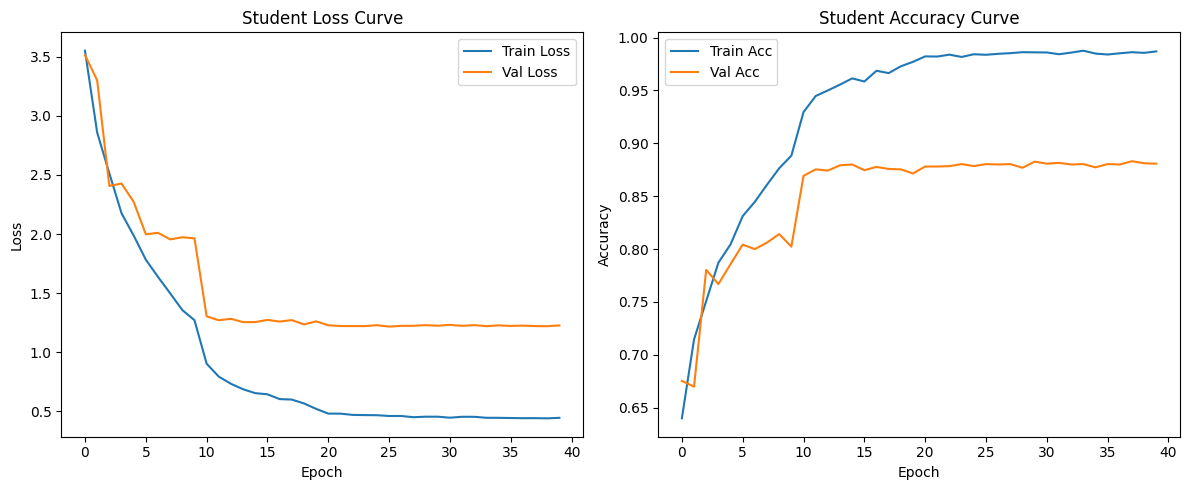

KD Train Accuracy: 0.9876
KD Val Accuracy: 0.8831


In [ ]:
# 22. Utility: Plot training and validation accuracy curves
def plot_accuracy_curves(train_accs, val_accs, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

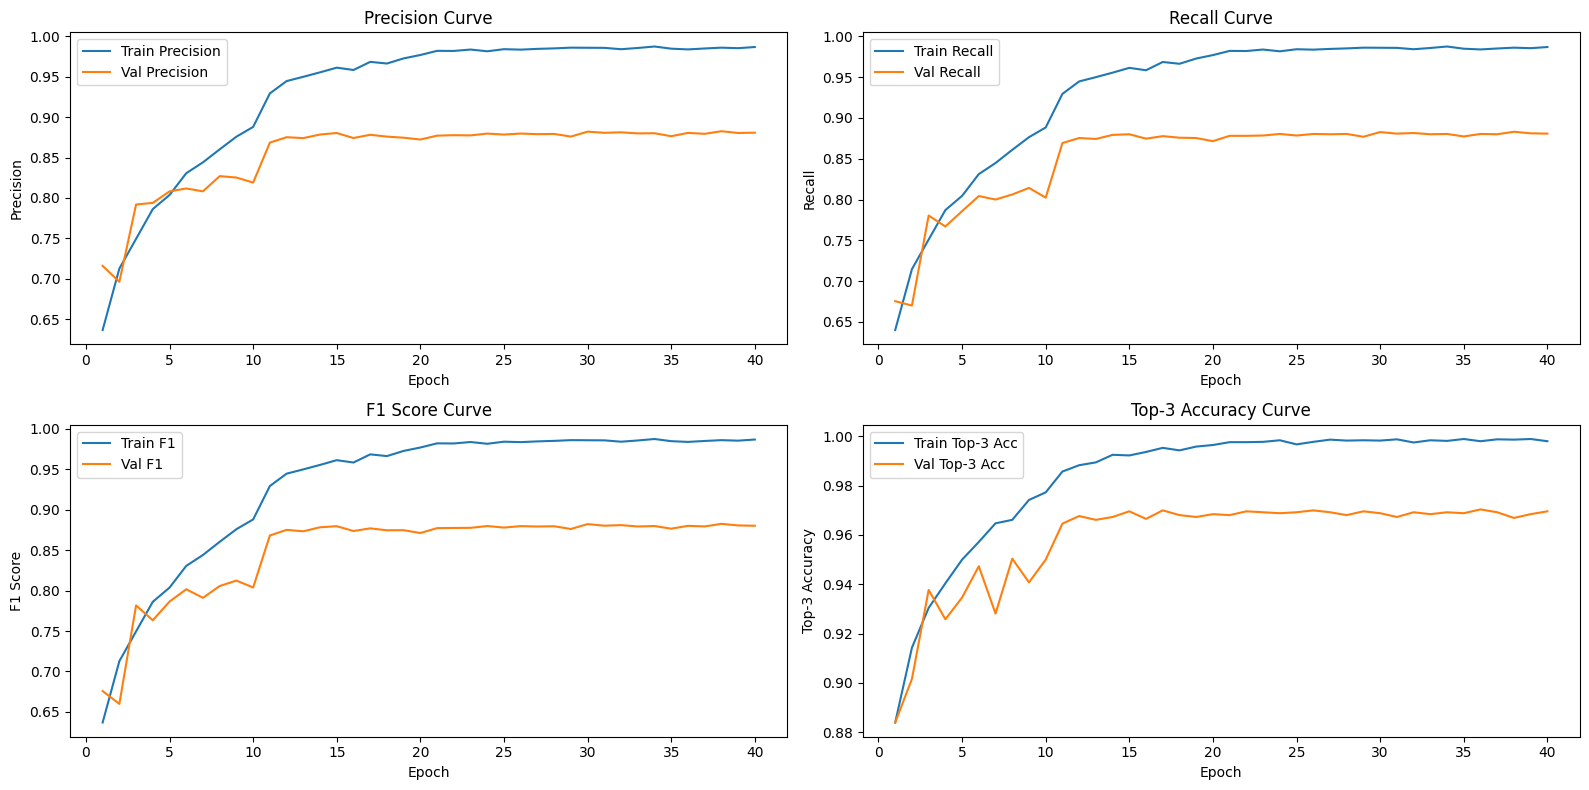

KD Precision: 0.8827
KD Recall: 0.8831
KD F1 Score: 0.8826
KD top-3 Accuracy: 0.9669


In [ ]:
# 23. Utility: Plot training and validation loss curves
def plot_loss_curves(train_losses, val_losses, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 3.1 KD resnet18 vs normoal resnet18

Normal ResNet18 Training:   2%|▏         | 1/60 [00:45<44:50, 45.60s/it]

Epoch 1/60 | Train Acc: 0.5054 | Val Acc: 0.6127


Normal ResNet18 Training:   3%|▎         | 2/60 [01:29<42:50, 44.32s/it]

Epoch 2/60 | Train Acc: 0.6365 | Val Acc: 0.6654


Normal ResNet18 Training:   5%|▌         | 3/60 [02:14<42:40, 44.91s/it]

...

Epoch 58/60 | Train Acc: 0.9917 | Val Acc: 0.8219


Normal ResNet18 Training:  98%|█████████▊| 59/60 [40:48<00:42, 42.24s/it]

Epoch 59/60 | Train Acc: 0.9818 | Val Acc: 0.8092


Normal ResNet18 Training: 100%|██████████| 60/60 [41:32<00:00, 41.55s/it]

Epoch 60/60 | Train Acc: 0.9945 | Val Acc: 0.8369


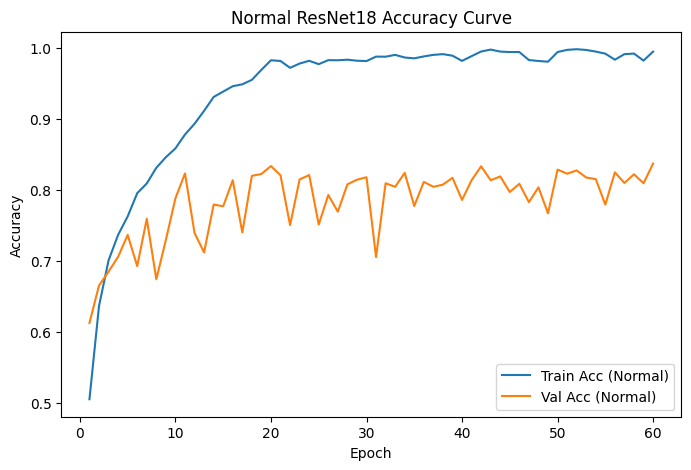

In [ ]:
# 24. Utility: Plot training and validation F1-score curves
def plot_f1_curves(train_f1s, val_f1s, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_f1s, label='Train F1')
    plt.plot(val_f1s, label='Val F1')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# 25. Utility: Print classification report
def print_classification_report(y_true, y_pred, target_names):
    print(classification_report(y_true, y_pred, target_names=target_names))

Normal Train Accuracy: 0.9978
Normal Val Accuracy: 0.8369


# Step 4 Predict labels in the testing set
1. Load the saved ResNet18 and move it to the selected device.
2. Do prediction using the images in the testing set.
3. Write the results into the CSV file for submission.

In [ ]:
# 26. Utility: Print confusion matrix
def print_confusion_matrix(y_true, y_pred, target_names):
    cm = confusion_matrix(y_true, y_pred)
    print('Confusion Matrix:')
    print(cm)

C:\Users\Wade Yan\AppData\Local\Temp\ipykernel_33576\2749093949.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet18.load_state_dict(torch.load("../models/resnet18_c

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# 27. Utility: Print shape of tensor
def print_tensor_shape(tensor, name):
    print(f"{name} shape: {tensor.shape}")

In [ ]:
# 28. Utility: Print first few elements of tensor
def print_tensor_head(tensor, name, n=5):
    print(f"{name} head: {tensor[:n]}")

Submission file saved as ../submission.csv
